In [ ]:
!pip3 install git+https://github.com/NetManAIOps/sktime.git
!pip3 install statsmodels

  Cloning https://github.com/NetManAIOps/sktime.git to /private/var/folders/09/vy9lbtvd6532vkq3yfrht5w40000gn/T/pip-req-build-7si40dy2
  Running command git clone --filter=blob:none --quiet https://github.com/NetManAIOps/sktime.git /private/var/folders/09/vy9lbtvd6532vkq3yfrht5w40000gn/T/pip-req-build-7si40dy2
  Resolved https://github.com/NetManAIOps/sktime.git to commit c0f95e99260e0b9df4265901a277f1424c2a6bf6
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


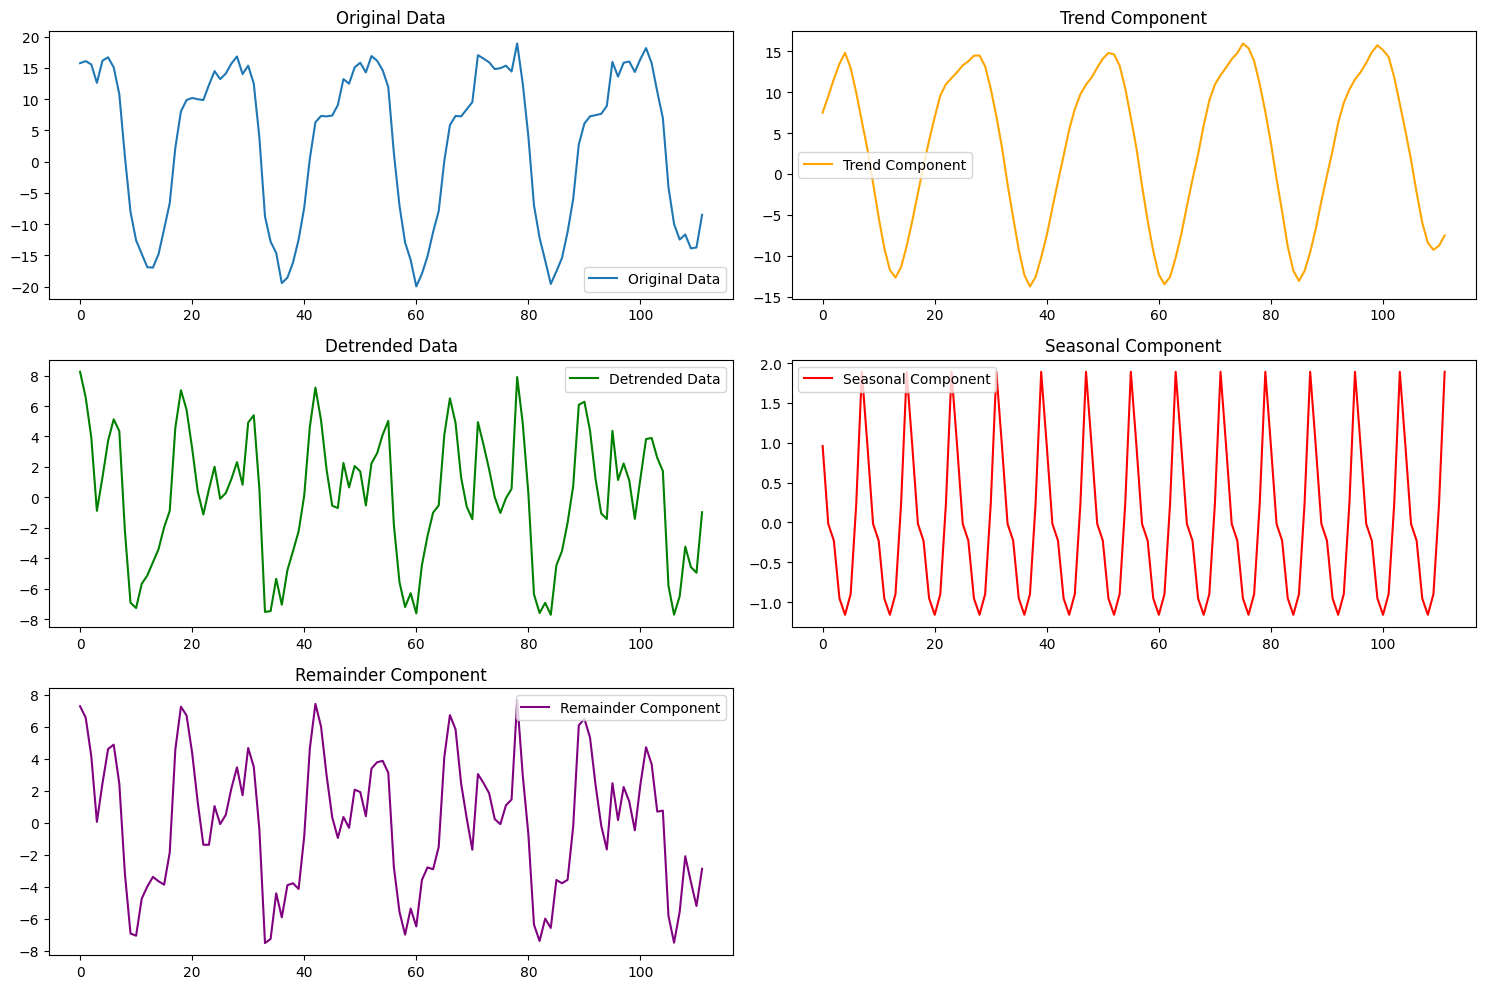

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sktime.datasets import load_etth_display

df = load_etth_display()
data = df['Best_Subsequence'].values

window_size = 8
trend = np.convolve(data, np.ones(window_size)/window_size, mode='same')

detrended = data - trend

seasonal_cycle = np.zeros_like(data)
for i in range(window_size):
    seasonal_cycle[i::window_size] = np.mean(detrended[i::window_size])

remainder = detrended - seasonal_cycle

plt.figure(figsize=(15, 10))
plt.subplot(3, 2, 1)
plt.plot(data, label='Original Data')
plt.title('Original Data')
plt.legend()

plt.subplot(3, 2, 2)
plt.plot(trend, label='Trend Component', color='orange')
plt.title('Trend Component')
plt.legend()

plt.subplot(3, 2, 3)
plt.plot(detrended, label='Detrended Data', color='green')
plt.title('Detrended Data')
plt.legend()

plt.subplot(3, 2, 4)
plt.plot(seasonal_cycle, label='Seasonal Component', color='red')
plt.title('Seasonal Component')
plt.legend()

plt.subplot(3, 2, 5)
plt.plot(remainder, label='Remainder Component', color='purple')
plt.title('Remainder Component')
plt.legend()

plt.tight_layout()
plt.show()


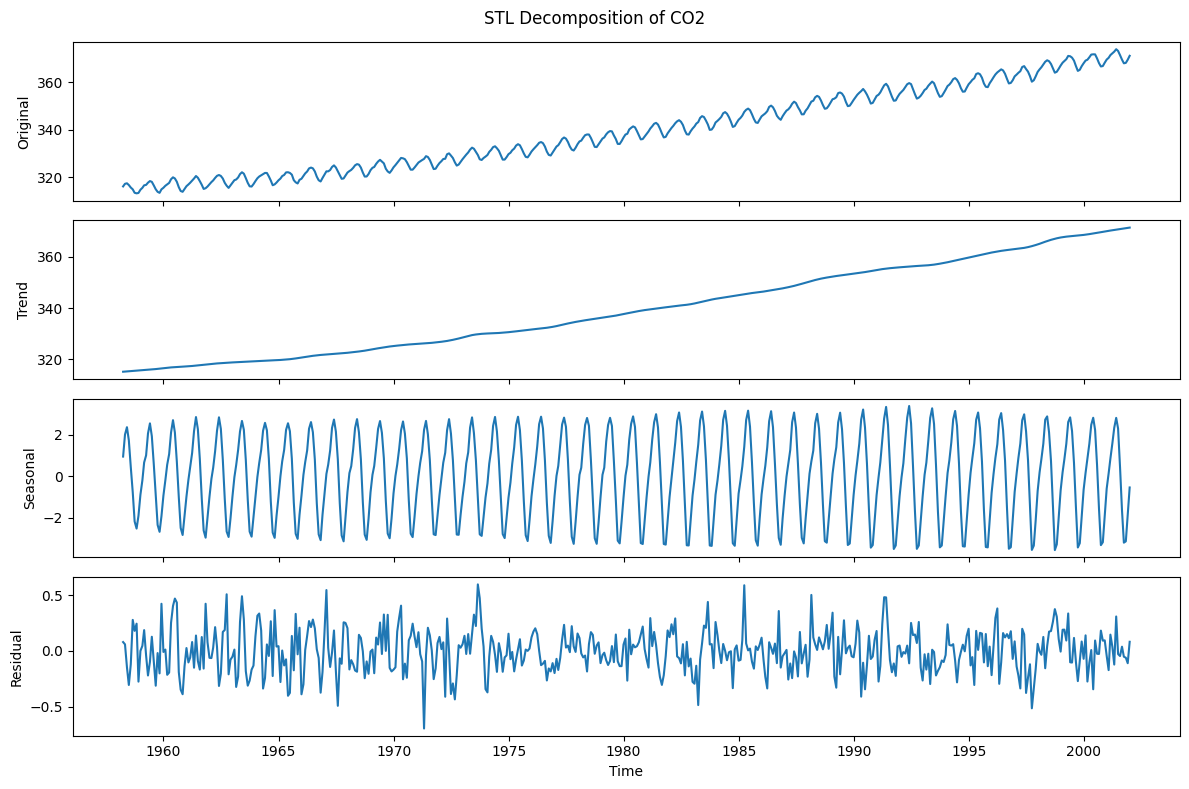

In [ ]:
# STL decomposition on CO2 (sktime has no CO2 loader; use statsmodels for data only)
import matplotlib.pyplot as plt
from statsmodels.datasets import co2 as co2_dataset

# Load CO2, interpolate NaN, resample to monthly
co2_df = co2_dataset.load_pandas().data
origin_ts = co2_df["co2"].interpolate().resample("ME").mean().dropna()

from sktime.transformations.series.detrend import STLTransformer
stl = STLTransformer(sp=12, return_components=True)
stl.fit(origin_ts)

components = stl.transform(origin_ts)

# Plot
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
axes[0].plot(origin_ts)
axes[0].set_ylabel("Original")
axes[1].plot(components["trend"])
axes[1].set_ylabel("Trend")
axes[2].plot(components["seasonal"])
axes[2].set_ylabel("Seasonal")
axes[3].plot(components["resid"])
axes[3].set_ylabel("Residual")
axes[3].set_xlabel("Time")

plt.suptitle("STL Decomposition of CO2")
plt.tight_layout()
plt.show()

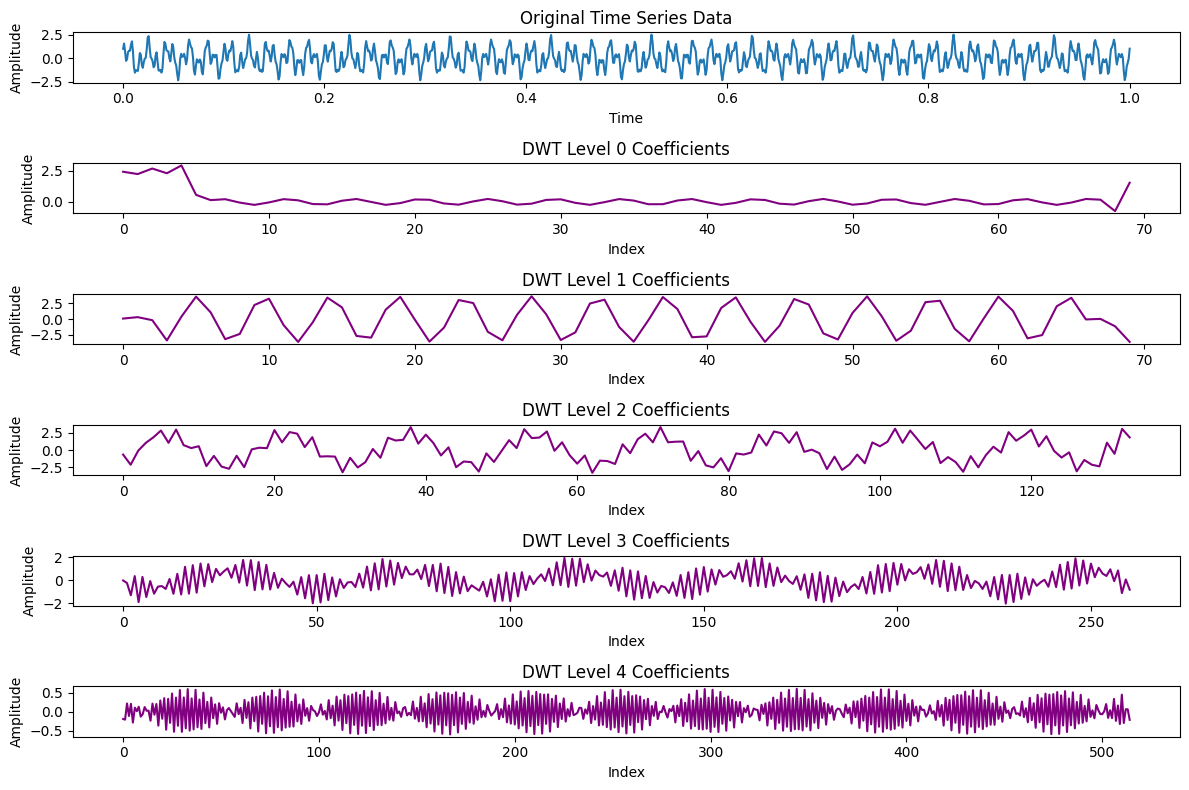

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

x = np.linspace(0, 1, 1024)
data = np.sin(2 * np.pi * 50 * x) + np.cos(2 * np.pi * 120 * x) + 0.5 * np.sin(2 * np.pi * 250 * x)

wavelet = 'db4'
coeffs = pywt.wavedec(data, wavelet, level=4)

plt.figure(figsize=(12, 8))
plt.subplot(6, 1, 1)
plt.plot(x, data, label='Original Data')
plt.title('Original Time Series Data')
plt.xlabel('Time')
plt.ylabel('Amplitude')
#plt.legend()

for i, coeff in enumerate(coeffs):
    plt.subplot(6, 1, i + 2)
    plt.plot(coeff, label=f'Level {i} Coefficients', color='purple')
    plt.title(f'DWT Level {i} Coefficients')
    plt.xlabel('Index')
    plt.ylabel('Amplitude')
    #plt.legend()

plt.tight_layout()
plt.show()
